In [1]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import mitsuba as mi
import drjit as dr
import torch
import numpy as np
import math
import time
from contextlib import contextmanager

mi.set_variant('cuda_ad_rgb')
scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)

@contextmanager
def timer(name = ""):
    start = time.time()
    try:
        yield
    finally:
        end = time.time()
        print(f"{name} Time elapsed: {end - start:.3f} seconds")

In [2]:
# randomly generate some cameras
cameras = []
cameras.append({'to_world': mi.Transform4f.look_at(origin=[0.6,0.2,0], target=[0,0,0], up=[0,1,0]), 'x_fov': 60, 'lightpos':[0.7,0.1,0]})

def set_camera(cam1):
    params['PerspectiveCamera.x_fov'] = cam1['x_fov']
    params['PerspectiveCamera.to_world'] = cam1['to_world']
    params['PointLight.position'] = cam1['lightpos']
set_camera(cameras[0])
params.update()
I_GT = mi.render(scene, params, spp=64).torch()

param_keys = ['wood_olive_wood_olive_basecolor.data', 'wood_olive_wood_olive_roughness.data']
tex_shape = params[param_keys[0]].shape[:2]

In [3]:
mi.util.convert_to_bitmap(I_GT)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [4]:
import random

@dr.wrap_ad(source='torch', target='drjit')
def render(tex0, tex1, *, spp=1, seed=None):
    params[param_keys[0]] = tex0
    params[param_keys[1]] = tex1
    params.update()
    if seed is None:
        seed = random.randint(0, 2147483646)
    return mi.render(scene, params, spp=spp, seed=seed, seed_grad=seed+1)

In [5]:
def prior(x, k=1000, thres=0.02):
    return k*(thres-x).clamp(min=0.0)**2 + k*(x-1+thres).clamp(min=0.0)**2
    
def U(theta, *, sigma=0.05):
    I = render(theta[...,0:3], theta[...,3:4])
    return ((I - I_GT).square()/(2*sigma**2) + math.log(sigma*math.sqrt(2*math.pi))).sum() + prior(theta).sum()

In [6]:
# Gradient descent
x1 = torch.rand((*tex_shape, 4), device='cuda', requires_grad=True)
opt = torch.optim.Adam([x1], lr=0.01)
for it in tqdm(range(100)):
    U(x1).backward()
    opt.step()
    opt.zero_grad()
    x1.data.clamp_(min=0, max=1)
mi.util.convert_to_bitmap(x1[256:512,32:288,0:3]) # custom

  0%|          | 0/100 [00:00<?, ?it/s]

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

In [7]:
from precondSGLD import pSGLD

In [8]:
# running mean & variance
class Welford:
    def __init__(self):
        self.n = 0
        self.m1 = 0
        self.m2 = 0
    def add(self, x):
        self.n += 1
        delta = x - self.m1
        self.m1 += delta / self.n
        delta2 = x - self.m1
        self.m2 += delta * delta2
    def mean(self):
        return self.m1
    def var(self, ddof=1):
        return self.m2 / (self.n-ddof)
    def std(self, ddof=1):
        return self.var(ddof=ddof).sqrt()

In [9]:
# SGLD

x1 = torch.rand((*tex_shape, 4), device='cuda', requires_grad=True)
opt = pSGLD([x1], lr=0.01)
stats = Welford()

texel_record_px = [(202,200),(400,150),(372,185)]
texel_record = [[] for px in texel_record_px]

for it in tqdm(range(10000)):
    U(x1).backward()
    opt.step()
    opt.zero_grad()
    x1.data.clamp_(min=0, max=1)

    with torch.no_grad():
        if it > 1000: # burn-in period
            stats.add(x1)
        for i,px in enumerate(texel_record_px):
            texel_record[i].append(x1[px].cpu().clone())

mi.util.convert_to_bitmap(x1[256:512,32:288,0:3]) # custom

  0%|          | 0/10000 [00:00<?, ?it/s]

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

In [10]:
mi.util.convert_to_bitmap(stats.mean()[256:512,32:288,0:3])

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

In [11]:
mi.util.convert_to_bitmap(stats.var().sum(axis=-1).sqrt()[256:512,32:288])

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

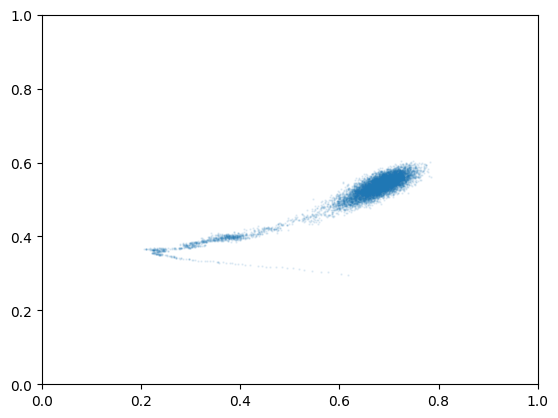

In [13]:
def trace_plot(xs):
    a = torch.stack(xs, axis=0)
    # plt.plot(a[:,1], a[:,3], linewidth=0.3, c='gray')
    plt.scatter(a[:,1], a[:,3], s=0.5, alpha=0.1)
    plt.xlim(0,1)
    plt.ylim(0,1)
trace_plot(texel_record[2][0:10000])

In [71]:
# SGLD

x1 = torch.rand((*tex_shape, 4), device='cuda', requires_grad=True)
opt = pSGLD([x1], lr=0.003)
stats = Welford()

texel_record_px = [(202,200),(400,150),(372,185)]
texel_record = [[] for px in texel_record_px]

for it in tqdm(range(10000)):
    U(x1).backward()
    opt.step()
    opt.zero_grad()
    x1.data.clamp_(min=0, max=1)

    with torch.no_grad():
        if it > 1000: # burn-in period
            stats.add(x1)
        for i,px in enumerate(texel_record_px):
            texel_record[i].append(x1[px].cpu().clone())

mi.util.convert_to_bitmap(x1[256:512,32:288,0:3]) # custom

  0%|          | 0/10000 [00:00<?, ?it/s]

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

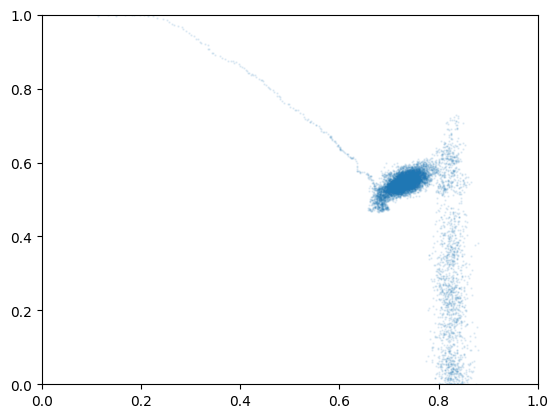

In [72]:
trace_plot(texel_record[2][0:10000])

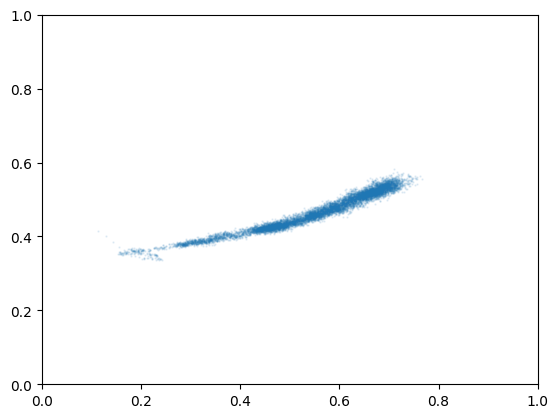

In [70]:
trace_plot(texel_record[2][0:10000])

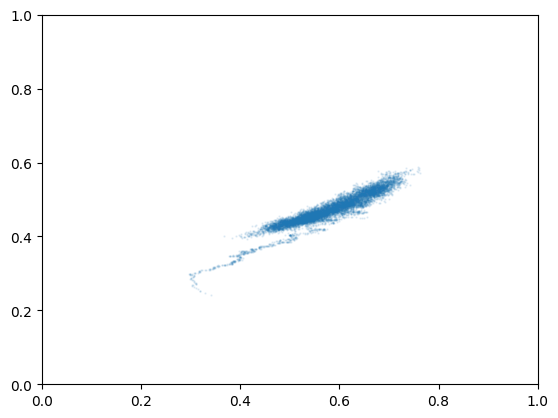

In [68]:
trace_plot(texel_record[2][0:10000])

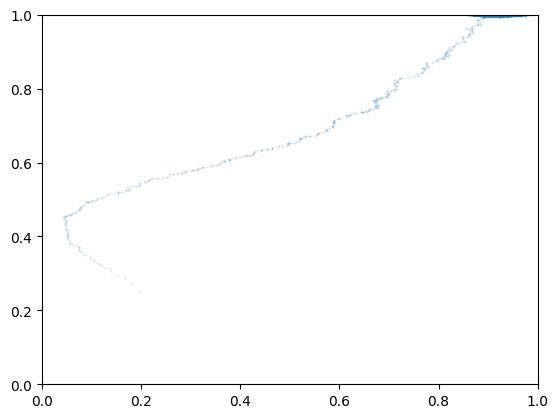

In [66]:
trace_plot(texel_record[2][0:10000])